## State of the Seabed

### Packages

In [2]:
# Packages
from pathlib import Path

import geopandas as gpd
from dotenv import load_dotenv
from resplotlib import rpc

from state_of_the_delta import Memo

# Load environment variables
load_dotenv()

c:\Users\white_rn\Documents\GitHub\state-of-the-delta\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

### Settings

In [3]:
# Directories
repo_path = Path.cwd().parents[0]
dir_path_templates = repo_path / "data" / "00_templates"
dir_path_areas = repo_path / "data" / "01_areas"
dir_path_figures = repo_path / "data" / "02_figures"
dir_path_memos = repo_path / "data" / "03_memos"

# Area of interest
area_name = "north_sea"

# Template name
template_name = "state_of_the_seabed"

In [4]:
# Read geometries
gdf_areas = gpd.read_file(dir_path_areas / f"{area_name}.geojson")

### Figures

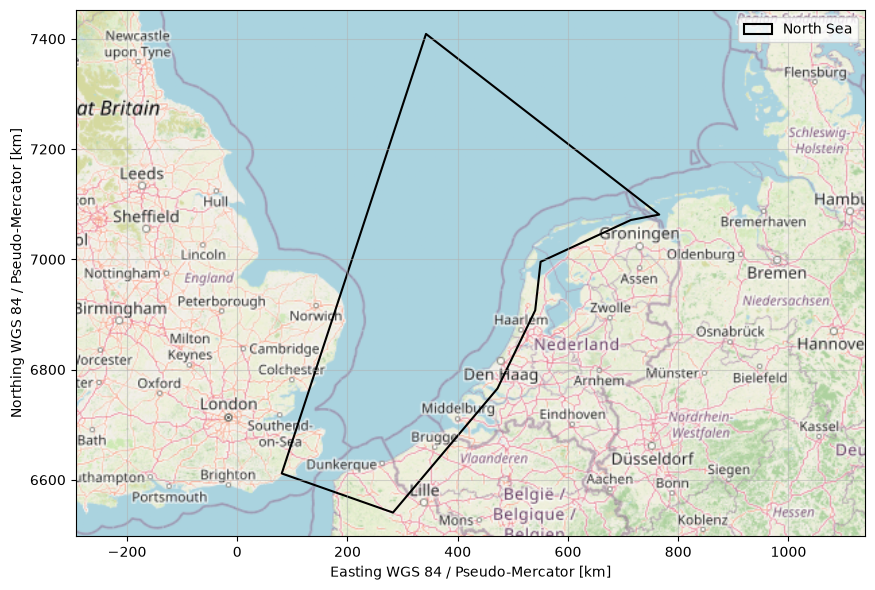

In [5]:
# Plot settings
bounds = gdf_areas.total_bounds
center = [(bounds[0] + bounds[2]) / 2, (bounds[1] + bounds[3]) / 2]

height = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 1.1
width = height * 1.5
xlim = [center[0] - width / 2, center[0] + width / 2]
ylim = [center[1] - height / 2, center[1] + height / 2]

# Plot map
fig, ax = rpc.subplots(1, figsize=(16, 6))
rpc.geometries(gdf_areas, ax=ax, style="aoi", label=f"{area_name}".replace("_", " ").title())
rpc.basemap(crs=gdf_areas.crs, ax=ax, style="osm", attribution=False, xlim=xlim, ylim=ylim)
ax.legend()
rpc.save(fig, file_path=dir_path_figures / f"{template_name}_{area_name}_map.png".lower().replace(" ", "_"))
rpc.show(fig)

### Memo

INFO:httpx:HTTP Request: POST https://openaicoastal.openai.azure.com/openai/deployments/text-embedding-3-large/embeddings?api-version=2024-12-01-preview "HTTP/1.1 200 OK"
INFO:azure.core.pipeline.policies.http_logging_policy:Request URL: 'https://searchcoastal.search.windows.net/indexes('minikennisbank_questions')/docs/search.post.search?api-version=2026-04-01'
Request method: 'POST'
Request headers:
    'Content-Type': 'application/json'
    'Content-Length': '63671'
    'Accept': 'application/json;odata.metadata=none'
    'x-ms-client-request-id': '1b6d7be5-aab7-11f1-94ec-005056acadae'
    'User-Agent': 'azsdk-python-search-documents/12.0.0 Python/3.12.14 (Windows-11-10.0.26200-SP0)'
    'api-key': 'REDACTED'
A body is sent with the request
INFO:azure.core.pipeline.policies.http_logging_policy:Response status: 200
Response headers:
    'Transfer-Encoding': 'chunked'
    'Content-Type': 'application/json; odata.metadata=none; odata.streaming=true; charset=utf-8'
    'Content-Encoding'


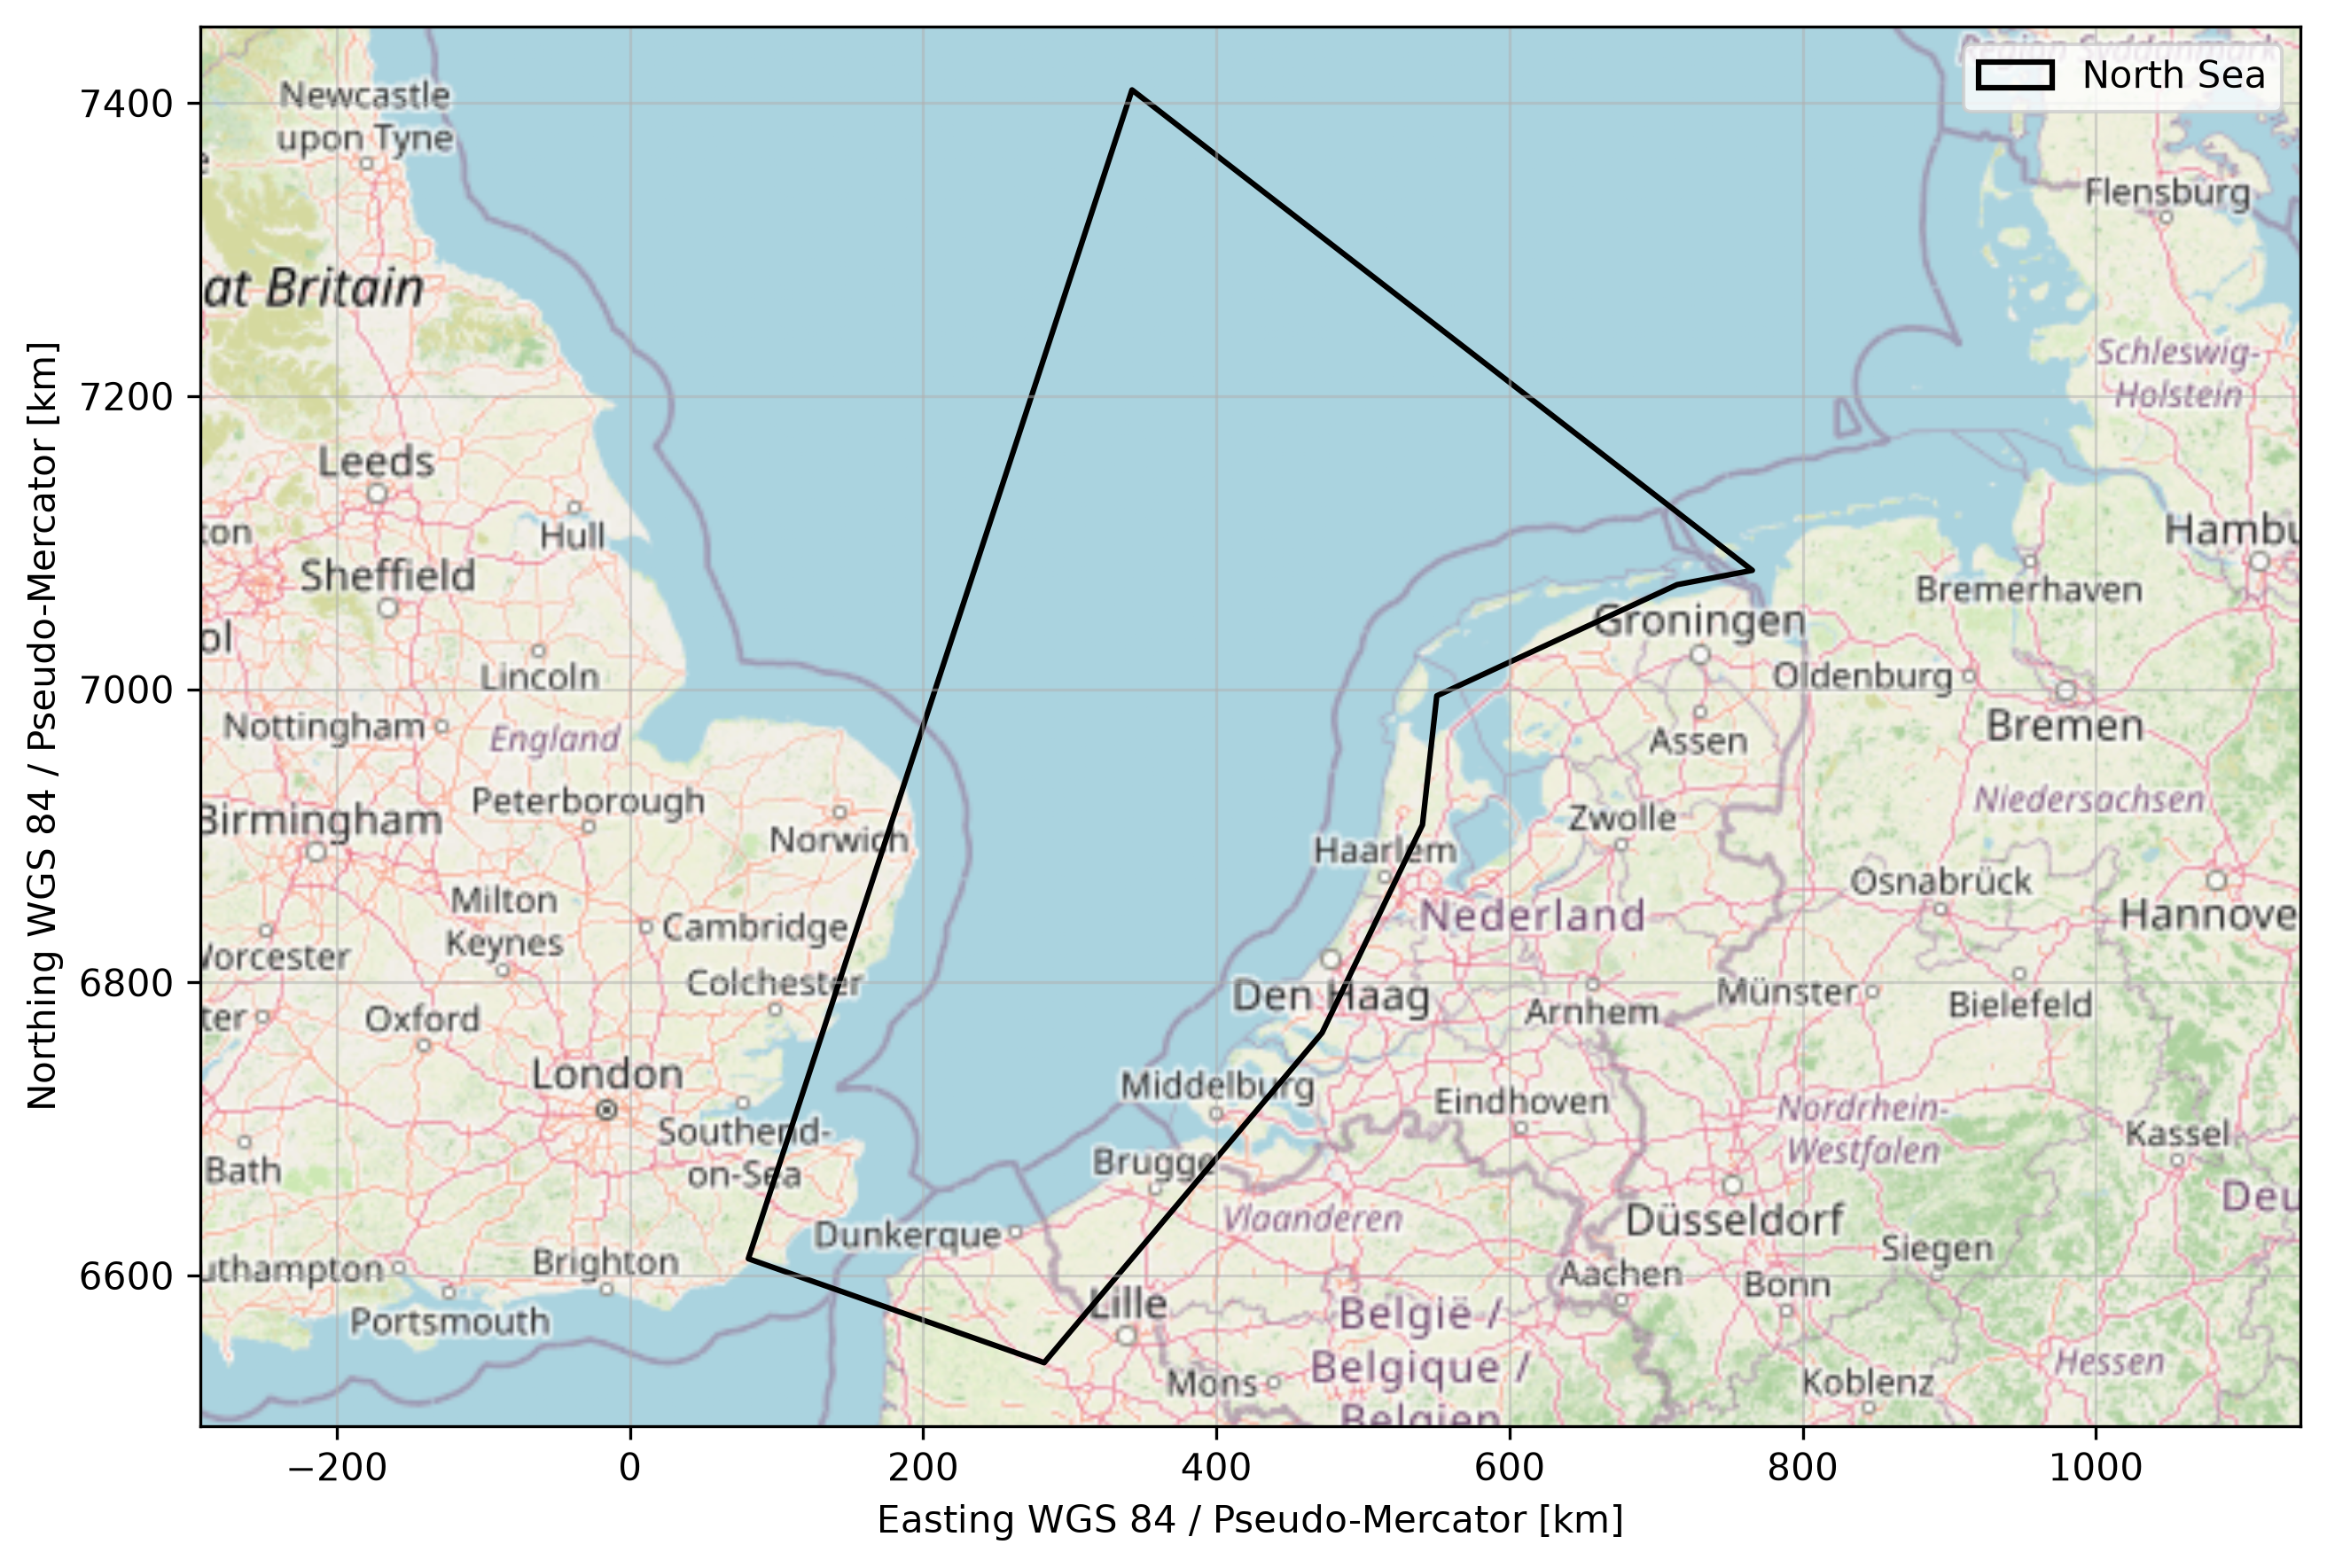

In [6]:
template = dir_path_templates / "state_of_the_seabed.md"
figures = {
    "Figure 1": dir_path_figures / f"{template_name}_{area_name}_map.png",
}
datasets = {
    "name": area_name,
    "area of interest": gdf_areas.__geo_interface__,
}

# Generate memo
memo = Memo(template=template, figures=figures, datasets=datasets)
memo.generate_content(rag_index_name="minikennisbank_questions")

# Save and display memo
memo.to_md(dir_path_memos / f"{template_name}_{area_name}_memo.md")
memo.to_html(dir_path_memos / f"{template_name}_{area_name}_memo.html")
memo.show()